<a href="https://colab.research.google.com/github/kkeshavsharma/TITANIC/blob/main/titanic_V0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **IMPORTING LIBRARIES**

In [ ]:
#kaggle titanic dataset is used in this project you can download it from kaggle website.
#download data from here = "https://www.kaggle.com/competitions/titanic/data"
import numpy as np
import pandas as pd
import sklearn

## **DATA LOADING**

In [ ]:
Data = pd.read_csv("train.csv")
Data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
Data.columns = Data.columns.map(lambda x: x.encode("ascii", "ignore"). decode("ascii"))

## **DATA SPLITING AND MODIFING**

In [ ]:
Data["Embarked"] = Data["Embarked"].fillna(Data["Embarked"].mode()[0])
Data["Embarked"]= Data["Embarked"].str.strip().str.upper()
Data["Embarked"]= Data["Embarked"].map({"Q":0, "C":1, "S":2})
Data["Sex"]= Data['Sex'].map({"female":0 , "male":1})
Data["Age"]= Data["Age"].fillna(Data["Age"].median())
Data["Fare"]= Data["Fare"].fillna(Data["Fare"].median())
Data["Survived"]= Data["Survived"].fillna(Data["Survived"].median())
a = Data.drop(columns = ["Name", "Cabin", "Ticket", "PassengerId"], axis = 1)

### **Cheaking Of NaN value If Any**

should be 0

In [ ]:
Data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## **DATA SEPRATION**

In [ ]:
x = a.drop('Survived', axis = 1)
y = a["Survived"]
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,1
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,2
887,1,0,19.0,0,0,30.0000,2
888,3,0,28.0,1,2,23.4500,2
889,1,1,26.0,0,0,30.0000,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.4, random_state = 50)
y_train

,Survived
214,0
1,1
665,0
568,0
527,0
...,...
132,0
289,1
109,1
480,0


# **TRAINING THE MODEL**

## **RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth = 3,random_state= 50)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=3, random_state=50)

## **Feature Importance**

In [ ]:
rf.feature_importances_

array([0.18417717, 0.47483341, 0.06840387, 0.03760266, 0.01982636,
       0.18590624, 0.02925028])

## **Making Prediction**

In [ ]:
y_pred = rf.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,

In [ ]:
rf.predict([[1,0,10.0,1,2,85.1000,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
rf.predict_proba([[1,0,10.0,1,2,85.1000,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.18318844, 0.81681156]])

In [ ]:
rf.predict([[3,1,22.0,1,0,7.2500,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
rf.predict_proba([[3,1,22.0,1,0,7.2500,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.85135554, 0.14864446]])

## **ACCURACY**

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8123249299719888

In [ ]:
rf.score(x_train, y_train)

0.8239700374531835

## **CONFUSION MATRIX AND CLASSIFICATION REPORT**

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[212   6]
 [ 61  78]]
              precision    recall  f1-score   support

           0       0.78      0.97      0.86       218
           1       0.93      0.56      0.70       139

    accuracy                           0.81       357
   macro avg       0.85      0.77      0.78       357
weighted avg       0.84      0.81      0.80       357



## **DATA VISUALIZATION**

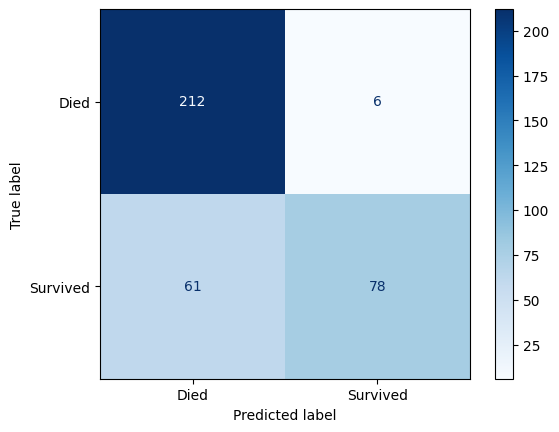

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Died", "Survived"]
)

disp.plot(cmap="Blues")
plt.show()
